<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Ingeniería y Ciencia de Datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Laboratorio de Procesamiento de Datos</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Módulo 2: Tratamiento de datos perdidos</h3>
    </div>
</div>

> Los datos faltantes no son simplemente "huecos" que rellenar o eliminar, son señales informativas cuyo mecanismo de generación condiciona la validez estadística y el rendimiento predictivo de algún modelo de ML.

> Los datos faltantes pueden imputarse, pero una imputación inadecuada destruye la varianza, distorsiona las correlaciones y puede introducir sesgos irreparables.


### Flujo de Tratamiento de datos Faltantes


```mermaid
flowchart TD
    A[Diagnóstico y Visualización de Nulidad] --> B[Identificación del Mecanismo: MCAR / MAR / MNAR]
    B --> C{¿Porcentaje de Faltantes y Patrón?}
    C -->|Muy alto / Irrelevante| D[Eliminación / Filtrado por Umbral]
    C -->|Bajo / Univariado / Rápido| E[Imputación Univariada + Missing Indicator]
    C -->|Datos Temporales / Ordenados| F[Forward/Backward Fill e Interpolación]
    C -->|Relaciones Multivariadas Fuertes| G[Modelos Predictivos: KNN / MICE / MissForest]
    D & E & F & G --> H[Validación de Distribuciones y Evaluación en Pipeline ML]
```

#### ¿Por qué los datos faltantes son un reto crítico en Ciencia de Datos?

1. **Incompatibilidad algorítmica:** La mayoría de los algoritmos de Machine Learning (`scikit-learn`, `statsmodels`, redes neuronales) no admiten matrices con `NaN`.
2. **Pérdida de potencia estadística:** La eliminación ingenua reduce el tamaño muestral efectivo ($N$), ensanchando los intervalos de confianza.
3. **Distorsión de la varianza y covarianza:** Asignar un valor constante a todos los faltantes concentra artificialmente la masa probabilística, reduciendo la varianza estimada y sobreestimando o alterando correlaciones.


## Diagnóstico y Visualización de Datos Faltantes

Antes de elegir cualquier tratamiento, el primer paso en el flujo de ingeniería de características es **diagnosticar**:
- ¿Cuántos datos faltan en cada variable (conteo y porcentaje)?
- ¿Se concentran los faltantes en observaciones específicas o en variables específicas?
- ¿Existe un patrón sistemático de ausencia o co-ocurrencia entre columnas?

### Diagnóstico tabular con `pandas`
La combinación de `.isna()`, `.sum()` y cálculos porcentuales permite construir una tabla resumen de nulidad.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [7]:
df=pd.read_csv('Data/API_SI.POV.DDAY_DS2.csv',encoding='latin-1',sep='\t')
df.head(10)

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.8,NaN,NaN
3,Albania,ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.8,NaN,1.6,1.1,0.9,1.3,NaN,NaN,NaN
4,Andorra,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Arab World,ARB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,United Arab Emirates,ARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
7,Argentina,ARG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.1,1.1,1.0,0.9,NaN,1.0,0.8,1.3,NaN,NaN
8,Armenia,ARM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.2,0.9,1.8,1.5,1.3,1.2,0.9,1.4,NaN,NaN
9,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 63 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  264 non-null    object 
 1   Country Code  264 non-null    object 
 2   1960          0 non-null      float64
 3   1961          0 non-null      float64
 4   1962          0 non-null      float64
 5   1963          0 non-null      float64
 6   1964          0 non-null      float64
 7   1965          0 non-null      float64
 8   1966          0 non-null      float64
 9   1967          1 non-null      float64
 10  1968          0 non-null      float64
 11  1969          1 non-null      float64
 12  1970          0 non-null      float64
 13  1971          1 non-null      float64
 14  1972          0 non-null      float64
 15  1973          0 non-null      float64
 16  1974          2 non-null      float64
 17  1975          2 non-null      float64
 18  1976          0 non-null      

In [9]:
# Tabla resumen de valores faltantes por columna
resumen_faltantes = pd.DataFrame({
    'Total Faltantes': df.isna().sum(),
    'Porcentaje Faltantes (%)': (df.isna().mean() * 100).round(2),
    'Tipo de Dato': df.dtypes
})
resumen_faltantes = resumen_faltantes[resumen_faltantes['Total Faltantes'] > 0].sort_values(by='Porcentaje Faltantes (%)', ascending=False)
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
resumen_faltantes.head(15)

Dimensiones del dataset: 264 filas x 63 columnas


,Total Faltantes,Porcentaje Faltantes (%),Tipo de Dato
1960,264,100.00,float64
1961,264,100.00,float64
1962,264,100.00,float64
1963,264,100.00,float64
1964,264,100.00,float64
1965,264,100.00,float64
1966,264,100.00,float64
1968,264,100.00,float64
1970,264,100.00,float64
1972,264,100.00,float64


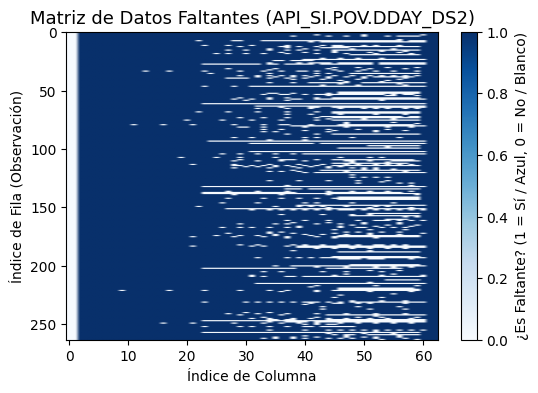

In [10]:
# Visualización de la matriz booleana de faltantes con imshow
dfcopy = df.isna()

plt.figure(figsize=(6, 4))
plt.imshow(dfcopy, cmap='Blues', aspect='auto')
plt.colorbar(label='¿Es Faltante? (1 = Sí / Azul, 0 = No / Blanco)')
plt.title('Matriz de Datos Faltantes (API_SI.POV.DDAY_DS2)', fontsize=13)
plt.xlabel('Índice de Columna')
plt.ylabel('Índice de Fila (Observación)')
plt.show()

### Visualización Especializada con `missingno`

La librería `missingno` proporciona un conjunto de herramientas gráficas diseñadas específicamente para diagnosticar el comportamiento y la correlación entre valores faltantes:

1. **`msno.bar`**: Muestra la proporción de datos presentes por variable y el conteo absoluto en el eje superior.
2. **`msno.matrix`**: Mapa visual de la matriz completa con un indicador lateral (*sparkline*) que muestra la completitud de cada fila (mínimo y máximo de columnas presentes por observación).

In [11]:
# Instalación de missingno si es necesario
#!pip install missingno

In [12]:
# Visualización de datos faltantes con missingno
import missingno as msno

In [13]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: >

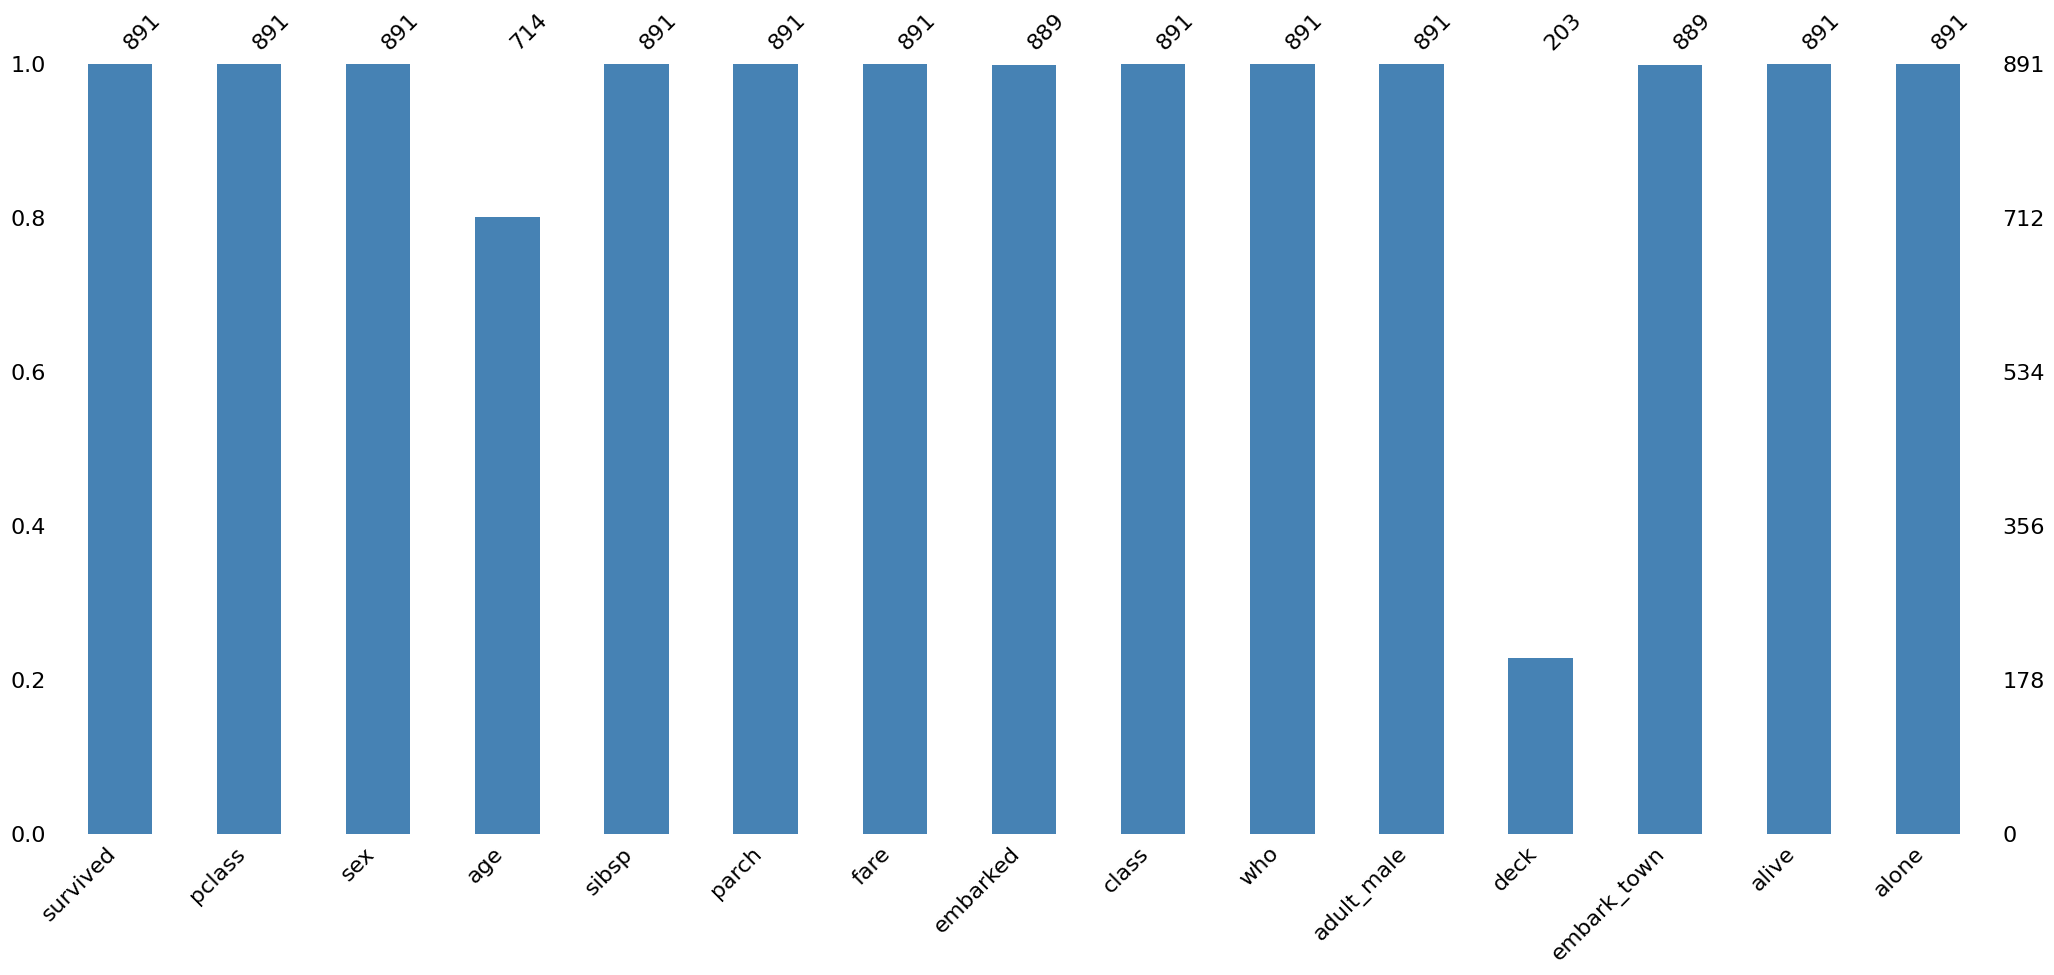

In [14]:
#Bar plot 
msno.bar(titanic_df, color='steelblue')
#color='steelblue')
#color="tomato")
#color="tab:green")

<Axes: >

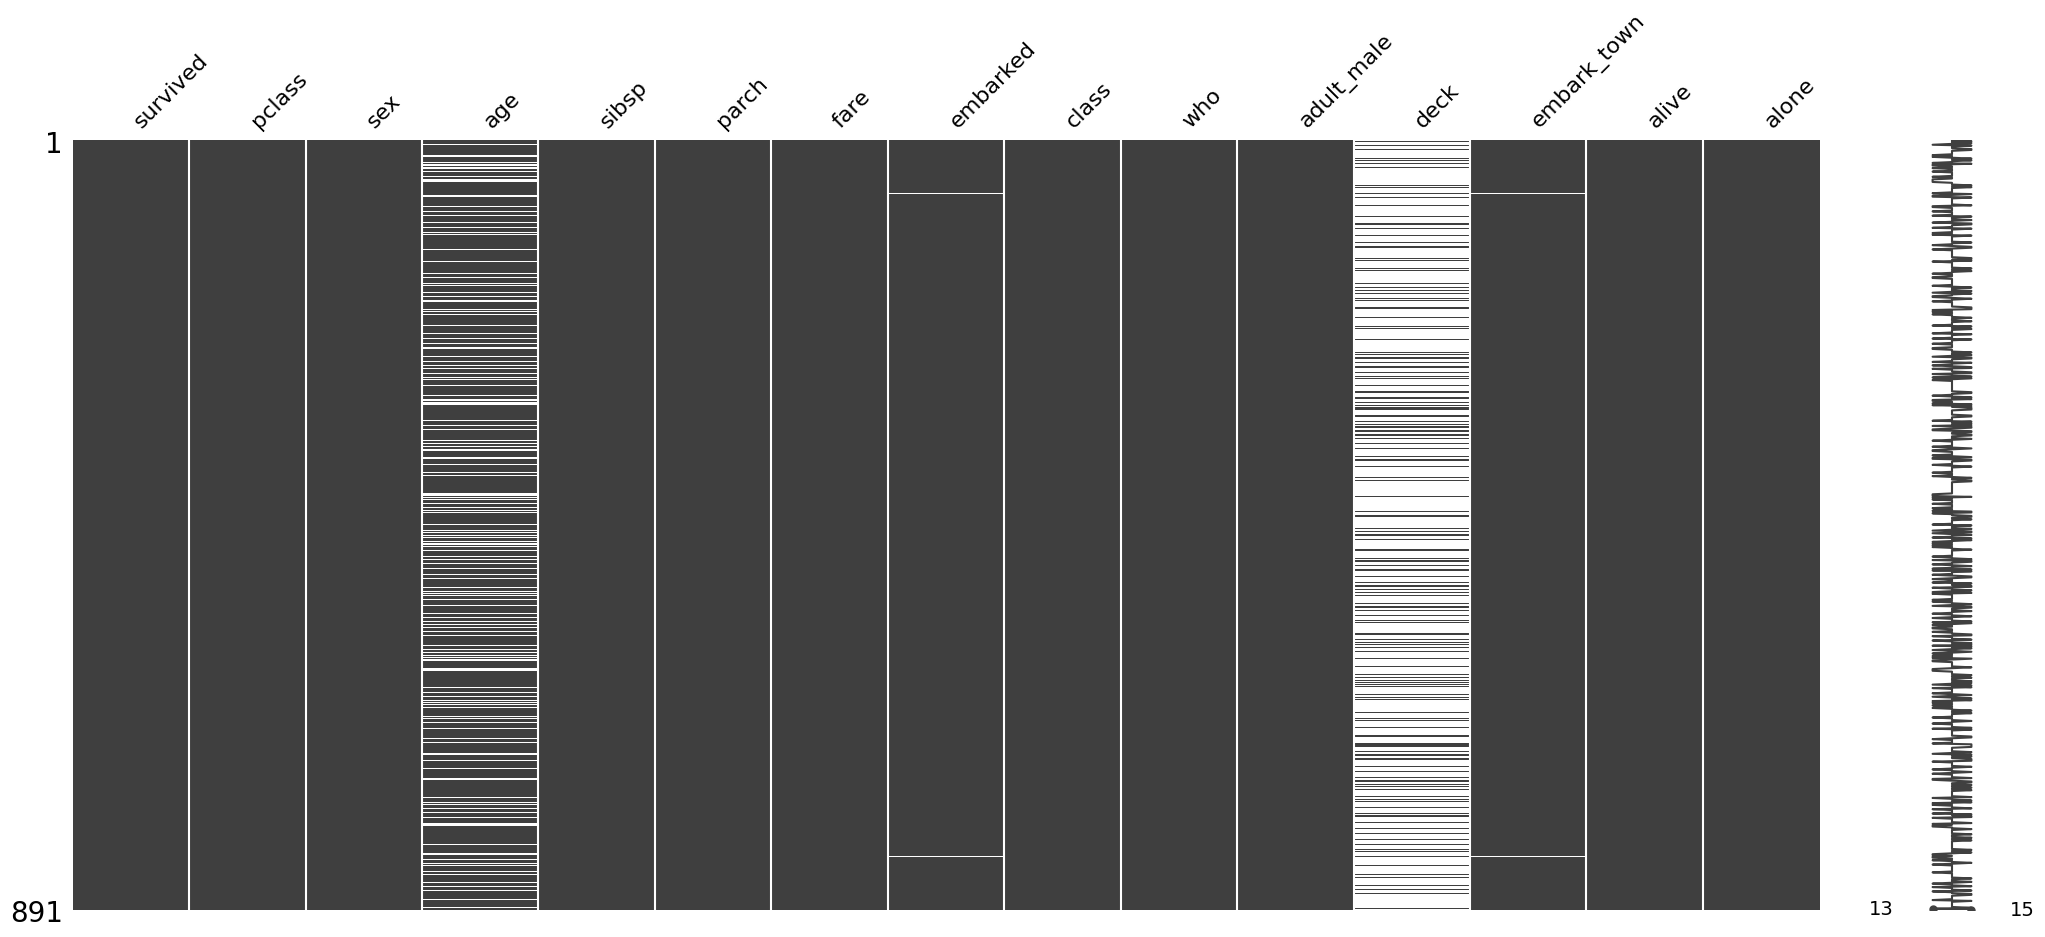

In [15]:
msno.matrix(titanic_df)

##  Clasificación de Datos Faltantes (Taxonomía de Rubin, 1976)

Donald Rubin (1976) formalizó matemáticamente los mecanismos generadores de datos faltantes.

Sea $Y = (Y_{\text{obs}}, Y_{\text{mis}})$ la matriz de datos completa, donde $Y_{\text{obs}}$ representa los valores observados y $Y_{\text{mis}}$ los valores ausentes. Definimos la **matriz indicadora de ausencia** $M$ con elementos:

$$
M_{ij} = \begin{cases} 1 & \text{si } Y_{ij} \text{ es faltante (NaN)} \\ 0 & \text{si } Y_{ij} \text{ es observado} \end{cases}
$$

El comportamiento de $M$ define los tres mecanismos fundamentales:

```mermaid
flowchart TD
    A[Mecanismos de Pérdida] --> B[MCAR<br/>Completamente al Azar]
    A --> C[MAR<br/>Al Azar]
    A --> D[MNAR<br/>No al Azar]

    
    B --> B1[No depende de nada observado ni no observado]

    C --> C1[Depende solo de lo observado<br/>ej. edad predice ingreso]

    D --> D1[Depende del propio valor no observado<br/>ej. salario alto se oculta]

    style B fill:#c8e6c9,stroke:#2e7d32
    style C fill:#fff9c4,stroke:#f9a825
    style D fill:#ffcdd2,stroke:#c62828
```

<img src="Figures/tipo_faltante.png" width="550" style="display: block; margin: auto; border-radius: 8px;">

En general conviene tratar la clasificación como una **hipótesis de trabajo**: se parte de MCAR como caso más simple, se busca evidencia de dependencia con variables observadas (MAR) y, si ni así se explica el patrón, se considera MNAR.

### ¿Cómo distinguirlos en la práctica?

La taxonomía es un modelo teórico sobre el **mecanismo generador** de la ausencia, no una propiedad que se lea directamente en una columna. En la práctica se infiere combinando tres fuentes de evidencia:

1. **Conocimiento del dominio:** ¿Por qué razón física, operativa o humana podría faltar este dato? (falla de equipo, política de captura, comportamiento del respondiente).
2. **Evidencia estadística:** ¿La ausencia de una variable se correlaciona con otras variables observadas?.
3. **Imposibilidad de prueba directa para MNAR:** No existe un test que confirme MNAR usando solo los datos disponibles, porque por definición depende del valor no observado, se sostiene con argumentos de dominio y, si es posible, con datos externos de validación.

### 1. MCAR (Missing Completely at Random)

**Definición:** La probabilidad de que un valor falte es totalmente independiente de los valores observados y de los valores ausentes. Los datos observados son una submuestra aleatoria simple de la población original.

**Propiedades clave:**
- Eliminar filas incompletas (*listwise deletion*) **no introduce sesgo** en las medias ni en los coeficientes de regresión, pero reduce la potencia estadística ($N$ menor).
- La imputación por media/mediana preserva la media muestral, pero contrae la varianza.

**Ejemplos en la vida real:**
1. Un tubo de ensayo se rompe accidentalmente en el laboratorio.
2. Pérdida aleatoria de paquetes de red en un sensor IoT.
3. Un encuestado salta una página entera por descuido físico.

4. **Manufactura:** Un sensor de temperatura en una línea de producción falla intermitentemente por una soldadura defectuosa, sin relación con la temperatura real medida ni con ninguna otra variable del proceso.
5. **Retail:** Un lector de código de barras en punto de venta falla de forma esporádica por suciedad en el lente, independientemente del producto, precio o sucursal.
6. **Salud:** Se extravía una muestra de sangre en el laboratorio clínico por un error administrativo de etiquetado, sin relación con el estado de salud del paciente.

> En la práctica, MCAR puro es poco frecuente en datos observacionales (encuestas, sistemas administrativos); es más común en fallas técnicas o de captura completamente ajenas al fenómeno medido.

In [17]:
# Ejemplo MCAR: Simulación
import numpy as np
import pandas as pd

np.random.seed(42)
data = pd.DataFrame({
    'edad': np.random.randint(20, 60, 100),
    'ingreso': np.random.randint(20000, 80000, 100)
})
# Introducimos valores faltantes aleatoriamente (MCAR)
mask = np.random.rand(*data.shape) < 0.1
data_mcar = data.mask(mask)
print('Datos con valores faltantes MCAR:')
print(data_mcar.head())

Datos con valores faltantes MCAR:
   edad  ingreso
0  58.0      NaN
1  48.0  55222.0
2  34.0  31837.0
3  27.0  34039.0
4  40.0  78148.0


### 2. MAR (Missing At Random)

**Definición:** La probabilidad de que un dato esté ausente depende de otras variables observadas en el dataset, pero condicional a esas variables, la ausencia no depende del valor que falta.

>  A pesar de llamarse "aleatorio", **no es aleatorio simple**. Es aleatorio *condicional* a las variables observadas.

**Propiedades clave:**
- La eliminación de casos completos (*listwise deletion*) **introduce sesgo**.

**Ejemplos:**
1. En encuestas de salud, los pacientes de mayor edad omiten con mayor frecuencia preguntas sobre ingresos económicos; pero dentro del mismo grupo de edad, la omisión es aleatoria.
2. En el dataset *Titanic*, la probabilidad de que falte `Age` es mucho mayor para pasajeros de 3ra clase (`Pclass = 3`) que para los de 1ra clase.

3. **Recursos Humanos:** los empleados con contrato de medio tiempo (variable observada) no reportan horas extra con más frecuencia que los de tiempo completo; dentro de cada tipo de contrato, la omisión ya no depende de cuántas horas extra trabajaron realmente.
4. **Educación:** los estudiantes de escuelas rurales (ubicación observada) tienen mayor tasa de resultados faltantes en un examen estandarizado por problemas logísticos de aplicación, no por su desempeño académico individual.
5. **E-commerce:** los usuarios que compran desde dispositivos móviles (canal observado) dejan en blanco el campo "dirección de facturación" con más frecuencia que quienes compran desde escritorio, independientemente del monto de la compra.

> Nota práctica: MAR es el supuesto más común y más útil en Ciencia de Datos, porque justifica el uso de técnicas multivariadas (KNN, MICE) que aprovechan variables correlacionadas para producir imputaciones no sesgadas.

In [18]:
# Ejemplo MAR: Simulación
data_mar = data.copy()
# Si la edad es mayor a 50, hay más probabilidad de que ingreso sea NaN
prob = np.where(data_mar['edad'] > 50, 0.4, 0.05)
mask = np.random.rand(len(data_mar)) < prob
data_mar.loc[mask, 'ingreso'] = np.nan
print('Datos con valores faltantes MAR:')
print(data_mar.head(10))

Datos con valores faltantes MAR:
   edad  ingreso
0    58      NaN
1    48      NaN
2    34  31837.0
3    27  34039.0
4    40  78148.0
5    58  50818.0
6    38  39115.0
7    42      NaN
8    30  44538.0
9    30  62530.0


### 3. MNAR (Missing Not At Random / Non-Ignorable)

**Definición:** La probabilidad de que un valor falte depende directamente del propio valor no observado, incluso tras controlar por todas las variables observadas disponibles.

**Consecuencias y Estrategias en Feature Engineering:**
- Es el escenario más desafiante: los métodos estándar (media, mediana, KNN, MICE) resultan **sesgados**.
- La ausencia en sí misma constituye una variable latente de alto poder predictivo.
- **Estrategia fundamental:** Crear un **Indicador de Ausencia** (*Missing Indicator*) como característica binaria explícita ($I(\text{variable is NaN})$) y usar modelos basados en árboles (XGBoost, LightGBM, Random Forest) o modelos de selección de Heckman / modelos de mezcla de patrones (*pattern-mixture models*).

**Ejemplos:**
1. En encuestas de compensación, ejecutivos con salarios extremadamente altos tienden a omitir la pregunta de salario.
2. En ensayos clínicos sobre depresión, pacientes con síntomas más severos abandonan el estudio (*dropout* por agravamiento del cuadro).

3. **Encuestas sensibles:** en cuestionarios sobre consumo de alcohol o sustancias, las personas con mayor consumo real tienden a subreportar o dejar la pregunta en blanco, precisamente por el valor que se está midiendo.
4. **IoT / Ambiental:** un sensor de calidad del aire puede saturarse y dejar de reportar lecturas justo cuando la concentración de contaminantes es extremadamente alta, es decir, la ausencia depende del propio valor no observado.
5. **Plataformas digitales:** los clientes muy insatisfechos (que dejarían la calificación más baja) abandonan la plataforma sin completar la reseña, dejando ese dato ausente precisamente por lo negativo de su experiencia.


In [19]:
# Ejemplo MNAR: Simulación
data_mnar = data.copy()
# Mayor probabilidad de ser NaN si el ingreso es alto
prob = (data_mnar['ingreso'] > 60000).astype(float) * 0.5 + 0.05
mask = np.random.rand(len(data_mnar)) < prob
data_mnar.loc[mask, 'ingreso'] = np.nan
print('Datos con valores faltantes MNAR:')
print(data_mnar.head(10))

Datos con valores faltantes MNAR:
   edad  ingreso
0    58  43599.0
1    48  55222.0
2    34  31837.0
3    27  34039.0
4    40  78148.0
5    58  50818.0
6    38  39115.0
7    42  30965.0
8    30  44538.0
9    30  62530.0


##  Estrategias de Eliminación y Filtrado

La eliminación es el enfoque más directo. Existen tres variantes principales:

1. **Análisis de Casos Completos (*Listwise Deletion*):** Elimina cualquier fila (observación) que contenga al menos un valor faltante (`df.dropna()`).
   - **Ventaja:** Sencillo de implementar; compatible con cualquier algoritmo.
   - **Desventaja:** Pérdida masiva de datos y sesgo garantizado si el mecanismo es MAR o MNAR.
2. **Eliminación por Pares (*Pairwise Deletion*):** Utiliza todas las observaciones disponibles para cada par de variables al calcular covarianzas o correlaciones.
   - **Desventaja:** Las matrices de covarianza resultantes pueden no ser semidefinidas positivas, provocando errores en regresiones o análisis multivariados (PCA).
3. **Filtrado por Umbral de Nulidad (*Threshold Filtering*):**
   - Eliminar columnas (variables) con una tasa de faltantes superior a un umbral $\tau_{\text{col}}$ (ej. $> 60\%-70\%$), a menos que la ausencia sea una variable de negocio crítica.
   - Eliminar filas (registros) con una tasa de faltantes superior a $\tau_{\text{row}}$ (ej. $> 50\%$).
   - En pandas se utiliza el parámetro `thresh`: `df.dropna(thresh=min_datos_no_nulos)`.

In [20]:
dfcopy.head() #dataset indicando valores faltantes

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,False,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,False,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,False,True,True
3,False,False,True,True,True,True,True,True,True,True,...,True,False,True,False,False,False,False,True,True,True
4,False,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [21]:
#valores faltantes
dfcopy.sum()

Country Name      0
Country Code      0
1960            264
1961            264
1962            264
               ... 
2016            176
2017            185
2018            227
2019            264
2020            264
Length: 63, dtype: int64

In [22]:
np.where(dfcopy.sum()>263)

(array([ 2,  3,  4,  5,  6,  7,  8, 10, 12, 14, 15, 18, 61, 62]),)

In [23]:
np.where(dfcopy.sum(axis=1)>60)

(array([  0,   1,   4,   5,   9,  10,  20,  21,  25,  28,  29,  34,  36,
         47,  48,  49,  50,  55,  59,  60,  62,  66,  67,  71,  76,  82,
         86,  88,  89,  91,  94,  96, 100, 101, 103, 105, 106, 108, 121,
        123, 125, 126, 130, 133, 135, 140, 144, 145, 147, 153, 154, 159,
        162, 168, 170, 177, 178, 179, 180, 181, 186, 189, 190, 191, 195,
        196, 197, 198, 203, 206, 210, 211, 213, 216, 223, 226, 228, 229,
        234, 236, 238, 239, 251, 253, 254]),)

In [24]:
# Filtrado por umbral (Threshold Deletion) con pandas 
# Regla: conservar columnas con al menos el 40% de datos observados (eliminar columnas con >60% NaN)
# y conservar filas con al menos el 50% de columnas completas

umbral_col = int(0.40 * len(df))
df_filtrado_cols = df.dropna(axis=1, thresh=umbral_col)

umbral_filas = int(0.50 * df_filtrado_cols.shape[1])
df_filtrado_final = df_filtrado_cols.dropna(axis=0, thresh=umbral_filas)

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones tras filtrado de columnas (>60% NaN): {df_filtrado_cols.shape}")
print(f"Dimensiones tras filtrado final de filas (>50% NaN): {df_filtrado_final.shape}")

Dimensiones originales: (264, 63)
Dimensiones tras filtrado de columnas (>60% NaN): (264, 2)
Dimensiones tras filtrado final de filas (>50% NaN): (264, 2)


In [25]:
#Eliminación de datos por registros y variables
# Simulando un Dataset con valores faltantes
df_data=pd.DataFrame(np.random.randn(100,4)+10*np.random.rand(4),columns=['A','B','C','D'])
for c in df_data.columns[:-1]:
    inan=np.random.randint(100,size=np.random.randint(20))
    df_data.loc[inan, c]=np.nan

In [26]:
df_data

,A,B,C,D
0,4.563033,3.761074,3.196334,4.788033
1,5.635825,4.152419,0.566685,5.456015
2,4.784739,5.303147,NaN,8.263535
3,NaN,4.020411,5.194478,6.249489
4,5.536117,5.212974,NaN,5.964629
...,...,...,...,...
95,5.447589,NaN,4.148332,5.189871
96,3.350164,4.130823,4.402381,5.137008
97,5.109872,4.256285,5.401711,5.364840
98,NaN,NaN,5.392710,7.021684


In [27]:
# Eliminación de filas (Observaciones)
df_data.dropna()

,A,B,C,D
0,4.563033,3.761074,3.196334,4.788033
1,5.635825,4.152419,0.566685,5.456015
5,6.126004,6.462774,4.296049,5.270481
6,3.273420,6.371625,3.781613,6.259087
7,7.208559,4.637924,3.850184,7.143951
...,...,...,...,...
91,6.070635,6.011560,3.247903,5.648507
94,6.140349,5.778307,5.399700,6.752920
96,3.350164,4.130823,4.402381,5.137008
97,5.109872,4.256285,5.401711,5.364840


In [28]:
# Eliminación de columnas (Variables)
df_data.dropna(axis=1)

,D
0,4.788033
1,5.456015
2,8.263535
3,6.249489
4,5.964629
...,...
95,5.189871
96,5.137008
97,5.364840
98,7.021684


##  Métodos de Imputación Univariada

La imputación reemplaza cada valor faltante por una estimación plausible basada en la información observada de la **misma columna** (univariada) o de **múltiples columnas** (multivariada).

### Principios Fundamentales en Feature Engineering:
1. **Preservación de la forma de la distribución:** Los métodos univariados siempre reducen la varianza ($\sigma^2_{\text{imputado}} < \sigma^2_{\text{original}}$) y crean picos artificiales (*spikes*) en el valor imputado.
2. **Uso de Indicadores de Ausencia (*Missing Indicators*):** Para compensar la distorsión y capturar el mecanismo de pérdida, es una excelente práctica acompañar la imputación con una columna binaria $I(X = \text{NaN})$.

### 1. Imputación por Métricas de Tendencia Central

#### A. Imputación por la Media

Reemplaza cada valor faltante por la media aritmética de los valores observados:

$$\hat{x}_{i} = \bar{x}_{\text{obs}} = \frac{1}{N_{\text{obs}}} \sum_{j \in \text{Obs}} x_j$$

- **Ventajas:** Extremadamente rápida, preserva la media muestral bajo MCAR.
- **Desventajas:**
  - Solo aplicable a variables cuantitativas continuas simétricas (sensible a *outliers*).
  - Reduce la varianza muestral: $\text{Var}(X_{\text{imp}}) = \frac{N_{\text{obs}}-1}{N-1} \text{Var}(X_{\text{obs}})$.
  - Distorsiona correlaciones y covarianzas con otras variables.

In [29]:
# Crear un DataFrame de ejemplo
data = {
    'A': [1, 2, None, 4],
    'B': [5, None, None, 8],
    'C': [9, 10, 11, 12]
}
df = pd.DataFrame(data)
print('DataFrame original:')
print(df)

DataFrame original:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12


In [30]:
df.mean(numeric_only=True)

A     2.333333
B     6.500000
C    10.500000
dtype: float64

In [31]:
# Imputar con la media
df = df.fillna(df.mean(numeric_only=True))
df

,A,B,C
0,1.000000,5.0,9
1,2.000000,6.5,10
2,2.333333,6.5,11
3,4.000000,8.0,12


In [32]:
from sklearn.impute import SimpleImputer

# Imputar con la media
imp_mean = SimpleImputer(strategy='mean')
imp_mean.fit_transform(df)

array([[ 1.        ,  5.        ,  9.        ],
       [ 2.        ,  6.5       , 10.        ],
       [ 2.33333333,  6.5       , 11.        ],
       [ 4.        ,  8.        , 12.        ]])

In [33]:
pd.DataFrame(imp_mean.fit_transform(df), columns = df.columns)

,A,B,C
0,1.000000,5.0,9.0
1,2.000000,6.5,10.0
2,2.333333,6.5,11.0
3,4.000000,8.0,12.0


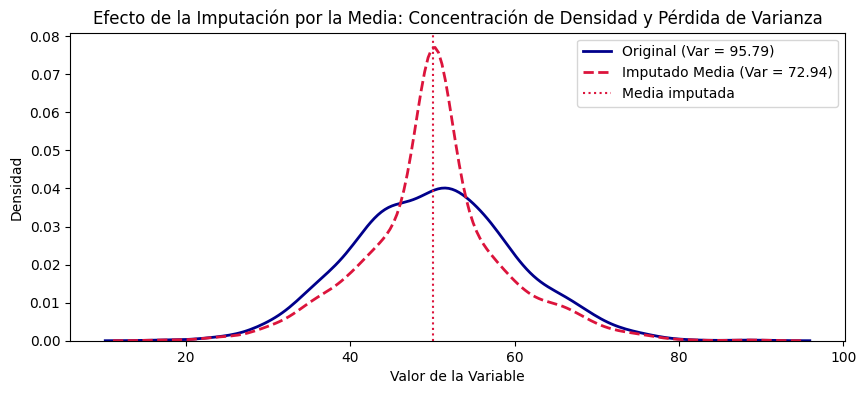

In [34]:
# Demostración visual de la reducción de varianza provocada por la imputación de la media
np.random.seed(42)
x_real = np.random.normal(loc=50, scale=10, size=1000)
x_con_nan = x_real.copy()
# 25% de valores faltantes
x_con_nan[np.random.rand(1000) < 0.25] = np.nan

x_imputado_media = pd.Series(x_con_nan).fillna(np.nanmean(x_con_nan))

plt.figure(figsize=(10, 4))
sns.kdeplot(x_real, label=f'Original (Var = {np.var(x_real):.2f})', color='darkblue', linewidth=2)
sns.kdeplot(x_imputado_media, label=f'Imputado Media (Var = {np.var(x_imputado_media):.2f})', color='crimson', linestyle='--', linewidth=2)
plt.axvline(np.nanmean(x_con_nan), color='crimson', linestyle=':', label='Media imputada')
plt.title('Efecto de la Imputación por la Media: Concentración de Densidad y Pérdida de Varianza', fontsize=12)
plt.xlabel('Valor de la Variable')
plt.ylabel('Densidad')
plt.legend()
plt.show()

#### B. Técnica Clave de Feature Engineering: Indicador de Ausencia (*Missing Indicator*)

Cuando imputamos un valor central (media o mediana), el modelo pierde la información de si el dato era originalmente ausente. Al añadir una **columna indicadora binaria** ($1$ si era faltante, $0$ si estaba presente), el modelo (especialmente regresión logística, SVM o redes neuronales) puede aprender un intercepto o peso separado para los registros imputados:

$$\text{Feature}_{\text{imputada}} = \text{impute}(X), \qquad \text{Feature}_{\text{is\_missing}} = I(X \text{ es NaN})$$

En `scikit-learn` se activa directamente con `add_indicator=True` dentro de `SimpleImputer`, `KNNImputer` o `IterativeImputer`.

In [35]:
# Uso de SimpleImputer con indicador binario de ausencia integrado
from sklearn.impute import SimpleImputer

imputer_con_indicador = SimpleImputer(strategy='median', add_indicator=True)
df_ejemplo = pd.DataFrame({
    'edad': [25, np.nan, 30, 45, np.nan, 50],
    'salario': [35000, 42000, np.nan, 80000, 95000, 110000]
})

matriz_imputada = imputer_con_indicador.fit_transform(df_ejemplo)
nombres_columnas = list(df_ejemplo.columns) + [f"{col}_is_missing" for col in df_ejemplo.columns]
df_resultado_indicador = pd.DataFrame(matriz_imputada, columns=nombres_columnas)
print("Dataset con imputación de mediana + Missing Indicators:")
df_resultado_indicador

Dataset con imputación de mediana + Missing Indicators:


,edad,salario,edad_is_missing,salario_is_missing
0,25.0,35000.0,0.0,0.0
1,37.5,42000.0,1.0,0.0
2,30.0,80000.0,0.0,1.0
3,45.0,80000.0,0.0,0.0
4,37.5,95000.0,1.0,0.0
5,50.0,110000.0,0.0,0.0


#### C. Imputación por la Mediana

Reemplaza los valores faltantes por el percentil 50 de la muestra observada:

$$\hat{x}_i = \text{Mediana}(X_{\text{obs}})$$

- **Ventaja:** Muy robusta frente a datos atípicos (*outliers*) y distribuciones asimétricas (sesgadas a la derecha o izquierda, como ingresos, precios o tiempos de espera).
- **Desventaja:** Al igual que la media, contrae artificialmente la varianza y altera las correlaciones multivariadas. Es la opción univariada por defecto preferida sobre la media en la práctica.

In [36]:
# Crear un DataFrame de ejemplo
data = {
    'A': [1, 2, None, 4],
    'B': [5, None, None, 8],
    'C': [9, 10, 11, 12]
}
df = pd.DataFrame(data)
print('DataFrame original:')
print(df)


DataFrame original:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12


In [37]:
# Imputar con la mediana
df_mediana = df.copy()
df_mediana = df_mediana.fillna(df.median(numeric_only=True))
df_mediana

,A,B,C
0,1.0,5.0,9
1,2.0,6.5,10
2,2.0,6.5,11
3,4.0,8.0,12


In [38]:
# Imputar con la mediana con la librería
# Imputar con la media
imp_median = SimpleImputer(strategy='median')
imp_median.fit_transform(df)

array([[ 1. ,  5. ,  9. ],
       [ 2. ,  6.5, 10. ],
       [ 2. ,  6.5, 11. ],
       [ 4. ,  8. , 12. ]])

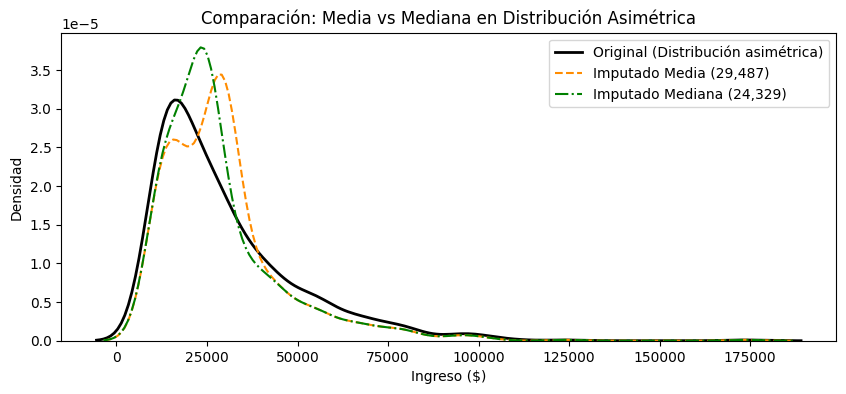

In [39]:
# Comparación gráfica: Imputación Media vs Mediana en presencia de asimetría y outliers
np.random.seed(42)
ingresos = np.random.exponential(scale=20000, size=800) + 10000  # Asimétrico a la derecha
ingresos_nan = ingresos.copy()
ingresos_nan[np.random.rand(800) < 0.20] = np.nan

imp_mean_vals = pd.Series(ingresos_nan).fillna(np.nanmean(ingresos_nan))
imp_median_vals = pd.Series(ingresos_nan).fillna(np.nanmedian(ingresos_nan))

plt.figure(figsize=(10, 4))
sns.kdeplot(ingresos, label='Original (Distribución asimétrica)', color='black', linewidth=2)
sns.kdeplot(imp_mean_vals, label=f'Imputado Media ({np.nanmean(ingresos_nan):,.0f})', color='darkorange', linestyle='--')
sns.kdeplot(imp_median_vals, label=f'Imputado Mediana ({np.nanmedian(ingresos_nan):,.0f})', color='green', linestyle='-.')
plt.title('Comparación: Media vs Mediana en Distribución Asimétrica', fontsize=12)
plt.xlabel('Ingreso ($)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

#### D. Imputación para Variables Categóricas: Moda vs. Categoría "Faltante / Desconocido"

Para variables cualitativas existen dos enfoques principales:

1. **Moda (Categoría más frecuente):**
   - Reemplaza el faltante por el valor que más se repite: $\hat{c} = \text{argmax}_{c} \text{conteo}(c)$.
   - **Recomendado:** Cuando la moda es abrumadoramente dominante ($> 80\%$) y la tasa de faltantes es muy baja ($< 5\%$).
   - **Riesgo:** Si la moda no es dominante, sobre-representa la categoría modal y desbalancea las frecuencias.

2. **Creación de una Categoría Explícita (`'Desconocido'` / `'Missing'`):**
   - Trata la ausencia como una nueva categoría válida en lugar de adivinar una categoría existente.
   - **Especialmente útil cuando el mecanismo es MNAR** o cuando la falta de respuesta tiene significado propio.

In [40]:
# Imputar con la moda
df_moda = df.copy()
moda = df.mode().iloc[0]
df_moda = df_moda.fillna(moda)
df_moda

,A,B,C
0,1.0,5.0,9
1,2.0,5.0,10
2,1.0,5.0,11
3,4.0,8.0,12


In [41]:
# Imputar con la moda
imp_mode = SimpleImputer(strategy='most_frequent')
imp_mode.fit_transform(df)

array([[ 1.,  5.,  9.],
       [ 2.,  5., 10.],
       [ 1.,  5., 11.],
       [ 4.,  8., 12.]])

##### Ejemplo

In [42]:
# Imputación por categoría constante ('Desconocido' o 'Missing')
imp_constant = SimpleImputer(strategy='constant', fill_value='Desconocido')
df_cat_ejemplo = pd.DataFrame({
    'ciudad': ['Guadalajara', 'CDMX', np.nan, 'Monterrey', np.nan, 'Guadalajara']
})

df_cat_imputado = pd.DataFrame(imp_constant.fit_transform(df_cat_ejemplo), columns=['ciudad'])
print("Frecuencias tras imputar como categoría explícita 'Desconocido':")
print(df_cat_imputado['ciudad'].value_counts())

Frecuencias tras imputar como categoría explícita 'Desconocido':
ciudad
Guadalajara    2
Desconocido    2
CDMX           1
Monterrey      1
Name: count, dtype: int64


In [43]:
# otro ejemplo titanic
# Seleccionar columnas categóricas con valores faltantes
df_mo_titanic = titanic_df
df_mo_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [44]:
df_mo_titanic.select_dtypes('object').columns

Index(['sex', 'embarked', 'who', 'embark_town', 'alive'], dtype='object')

In [45]:
df_mo_titanic.select_dtypes('object').isnull().sum()

sex            0
embarked       2
who            0
embark_town    2
alive          0
dtype: int64

In [46]:
titanic_cat_mode = SimpleImputer(strategy='most_frequent')
titanic_cat_mode.fit_transform(df_mo_titanic.select_dtypes('object'))

array([['male', 'S', 'man', 'Southampton', 'no'],
       ['female', 'C', 'woman', 'Cherbourg', 'yes'],
       ['female', 'S', 'woman', 'Southampton', 'yes'],
       ...,
       ['female', 'S', 'woman', 'Southampton', 'no'],
       ['male', 'C', 'man', 'Cherbourg', 'yes'],
       ['male', 'Q', 'man', 'Queenstown', 'no']],
      shape=(891, 5), dtype=object)

#### E. Imputación por Valor Arbitrario o Extremo

Consiste en reemplazar los valores faltantes por un número que no se encuentra en el rango natural de la variable (por ejemplo, $-999$, $-1$ o el percentil $99 + 3 \times \text{IQR}$).

- **Ventajas:** Muy eficaz para algoritmos basados en árboles de decisión (Decision Tree, Random Forest, XGBoost), ya que el árbol puede crear una partición limpia que aísle los datos faltantes en una rama propia.
- **Desventaja:** **Peligroso para modelos lineales o basados en distancia** (KNN, SVM, Regresión Lineal/Logística, Redes Neuronales), donde un valor extremo distorsiona fuertemente los gradientes y coeficientes.

In [47]:
# Imputación por valor arbitrario extremo (-999) para modelos de árboles
imp_arbitrario = SimpleImputer(strategy='constant', fill_value=-999)
df_num_arb = pd.DataFrame({'edad': [23, np.nan, 45, np.nan, 60]})
df_arb_res = pd.DataFrame(imp_arbitrario.fit_transform(df_num_arb), columns=['edad'])
print("Dataset imputado con valor extremo (-999):")
print(df_arb_res)

Dataset imputado con valor extremo (-999):
    edad
0   23.0
1 -999.0
2   45.0
3 -999.0
4   60.0


## Imputación en Series Temporales y Datos Secuenciales

Cuando las observaciones poseen un **orden cronológico o secuencial intrínseco**, la media global no tiene sentido físico. Se utilizan métodos basados en la trayectoria temporal:

### 1. Forward Fill (`ffill`) y Backward Fill (`bfill`)
- **Forward Fill (Última Observación Llevada Hacia Adelante - LOCF):** $x_t = x_{t-1}^*$. Asume que el estado del sistema persiste hasta que ocurra un nuevo evento.
- **Backward Fill (Próxima Observación Llevada Hacia Atrás - NOCB):** $x_t = x_{t+1}^*$.
- **Combinación robusta:** `df.ffill().bfill()` para asegurar que no queden nulos al inicio ni al final de la serie.

### 2. Interpolación Matemática (Lineal, Polinomial, Spline)
Calcula el valor faltante asumiendo una curva suave o recta entre los puntos conocidos adyacentes:

$$\hat{x}_t = x_{t_0} + \frac{x_{t_1} - x_{t_0}}{t_1 - t_0}(t - t_0)$$

En `pandas` se ejecuta con `.interpolate(method='linear')`, `.interpolate(method='quadratic')` o `.interpolate(method='time')`.

In [48]:
# Crear una serie temporal con valores faltantes
np.random.seed(0)
dates = pd.date_range('2023-01-01', periods=20)
values = np.random.randn(20).cumsum()
series = pd.Series(values, index=dates)

# Introducir valores faltantes
series.iloc[[3, 4, 10, 11, 12, 17]] = np.nan
print('Serie original con valores faltantes:')
print(series)


Serie original con valores faltantes:
2023-01-01     1.764052
2023-01-02     2.164210
2023-01-03     3.142948
2023-01-04          NaN
2023-01-05          NaN
2023-01-06     6.274121
2023-01-07     7.224209
2023-01-08     7.072852
2023-01-09     6.969633
2023-01-10     7.380232
2023-01-11          NaN
2023-01-12          NaN
2023-01-13          NaN
2023-01-14     9.861262
2023-01-15    10.305125
2023-01-16    10.638799
2023-01-17    12.132878
2023-01-18          NaN
2023-01-19    12.240788
2023-01-20    11.386692
Freq: D, dtype: float64


In [49]:
# Comparativa de técnicas temporales: ffill, bfill e interpolación lineal y spline
series_ffill = series.ffill()
series_bfill = series.bfill()
series_interp_lin = series.interpolate(method='linear')
series_interp_spline = series.interpolate(method='spline', order=2)

In [50]:
series_ffill

2023-01-01     1.764052
2023-01-02     2.164210
2023-01-03     3.142948
2023-01-04     3.142948
2023-01-05     3.142948
2023-01-06     6.274121
2023-01-07     7.224209
2023-01-08     7.072852
2023-01-09     6.969633
2023-01-10     7.380232
2023-01-11     7.380232
2023-01-12     7.380232
2023-01-13     7.380232
2023-01-14     9.861262
2023-01-15    10.305125
2023-01-16    10.638799
2023-01-17    12.132878
2023-01-18    12.132878
2023-01-19    12.240788
2023-01-20    11.386692
Freq: D, dtype: float64

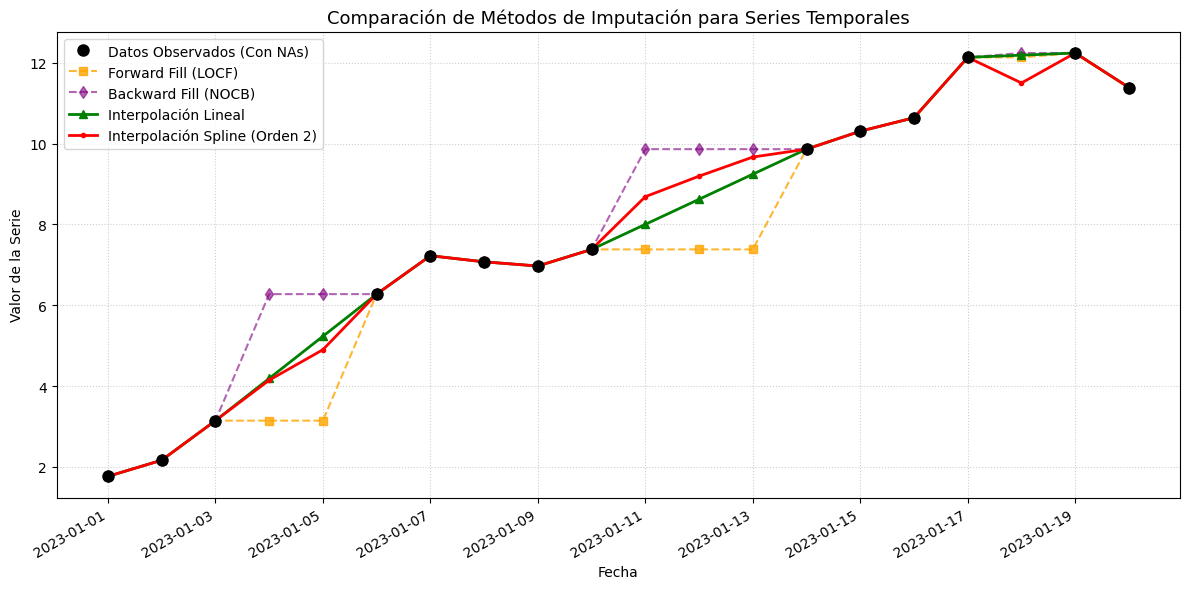

In [51]:
# Visualización comparativa de métodos temporales
plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, 'ko', markersize=8, label='Datos Observados (Con NAs)', zorder=5)
plt.plot(series_ffill.index, series_ffill.values, 's--', color='orange', alpha=0.8, label='Forward Fill (LOCF)')
plt.plot(series_bfill.index, series_bfill.values, 'd--', color='purple', alpha=0.6, label='Backward Fill (NOCB)')
plt.plot(series_interp_lin.index, series_interp_lin.values, 'g^-', linewidth=2, label='Interpolación Lineal')
plt.plot(series_interp_spline.index, series_interp_spline.values, 'r.-', linewidth=2, label='Interpolación Spline (Orden 2)')

plt.xticks(rotation=30, ha='right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True)
plt.title('Comparación de Métodos de Imputación para Series Temporales', fontsize=13)
plt.xlabel('Fecha')
plt.ylabel('Valor de la Serie')
plt.tight_layout()
plt.show()

- Es recomendable usar estos métodos solo cuando los datos tienen un orden natural (por ejemplo, tiempo).
- Si los valores faltantes están al inicio o final de la serie, forward fill o backward fill pueden no imputar todos los valores.
- Se pueden combinar ambos métodos para imputar valores al inicio y final:

```python
serie_imputada = serie.ffill().bfill()
```

## Imputación por Donantes (Hot Deck y Cold Deck)

Los métodos de donantes sustituyen los valores faltantes por valores reales observados de otros registros ("donantes").

### 1. Imputación Hot Deck
El donante proviene del **mismo conjunto de datos**.
- **Aleatorio simple:** Se extrae un valor al azar de la distribución observada ($x_{i,\text{imp}} = x_{j,\text{obs}}$). Preserva la distribución empírica original y la varianza, a diferencia de la media.
- **Estratificado / Por similitud:** Se divide el dataset en grupos/estratos (ej. por edad o género) y se selecciona un donante dentro del mismo grupo.

### 2. Imputación Cold Deck
El donante proviene de una **fuente externa o histórica** (ej. censo anterior, tabla estándar del sector).

$$x_{i,\text{imp}} = x_{k,\text{externo}}, \quad k \in \mathcal{D}_{\text{externo}}$$

In [52]:
# Simulación de datos
np.random.seed(42)
df = pd.DataFrame({
    'edad': np.random.randint(18, 65, 20),
    'ingreso': np.random.randint(10000, 50000, 20)
})
# Introducir valores faltantes
df.loc[[2, 5, 7, 12], 'ingreso'] = np.nan
print('Datos originales con valores faltantes:')
print(df)

Datos originales con valores faltantes:
    edad  ingreso
0     56  12433.0
1     46  15311.0
2     32      NaN
3     60  49188.0
4     25  27568.0
5     38      NaN
6     56  38693.0
7     36      NaN
8     40  37480.0
9     28  35658.0
10    28  28942.0
11    41  28431.0
12    53      NaN
13    57  10189.0
14    41  29118.0
15    20  45773.0
16    39  11899.0
17    19  11267.0
18    41  41551.0
19    61  21394.0


#### A. Hot Deck Aleatorio Simple
Preserva la varianza empírica muestreando con reemplazo de los datos observados:

In [53]:
# Imputación Hot Deck aleatoria
df_imp_hot_deck=df.copy()
donantes = df['ingreso'].dropna()
for idx in df_imp_hot_deck[df_imp_hot_deck['ingreso'].isnull()].index:
    df_imp_hot_deck.loc[idx,'ingreso'] = np.random.choice(donantes)
df_imp_hot_deck

,edad,ingreso
0,56,12433.0
1,46,15311.0
2,32,38693.0
3,60,49188.0
4,25,27568.0
5,38,49188.0
6,56,38693.0
7,36,35658.0
8,40,37480.0
9,28,35658.0


In [54]:
#grupo edad
df['grupo_edad'] = pd.cut(df['edad'], bins=[17, 30, 45, 65], labels=['Joven', 'Adulto', 'Mayor'])
df.head()

,edad,ingreso,grupo_edad
0,56,12433.0,Mayor
1,46,15311.0,Mayor
2,32,NaN,Adulto
3,60,49188.0,Mayor
4,25,27568.0,Joven


In [55]:
# Introducimos de nuevo valores faltantes para el ejemplo
df.loc[[2, 5, 7, 12], 'ingreso'] = np.nan
df_imp_hotdeck_group = df.copy()
df_imp_hotdeck_group.head(15)

,edad,ingreso,grupo_edad
0,56,12433.0,Mayor
1,46,15311.0,Mayor
2,32,NaN,Adulto
3,60,49188.0,Mayor
4,25,27568.0,Joven
5,38,NaN,Adulto
6,56,38693.0,Mayor
7,36,NaN,Adulto
8,40,37480.0,Adulto
9,28,35658.0,Joven


#### B. Hot Deck Estratificado por Grupo
El donante se selecciona dentro del mismo estrato (por ejemplo, mismo grupo de edad):

In [56]:
# Imputación Hot Deck por grupo
for idx, row in df_imp_hotdeck_group[df_imp_hotdeck_group['ingreso'].isnull()].iterrows():
    grupo = row['grupo_edad']
    donantes = df_imp_hotdeck_group[(df_imp_hotdeck_group['grupo_edad']==grupo) & (df_imp_hotdeck_group['ingreso'].notnull())]['ingreso']
    if not donantes.empty:
        df_imp_hotdeck_group.loc[idx, 'ingreso'] = np.random.choice(donantes)
    else:
        df_imp_hotdeck_group.loc[idx, 'ingreso'] = np.random.choice(df_imp_hotdeck_group['ingreso'].dropna())
df_imp_hotdeck_group
 

,edad,ingreso,grupo_edad
0,56,12433.0,Mayor
1,46,15311.0,Mayor
2,32,37480.0,Adulto
3,60,49188.0,Mayor
4,25,27568.0,Joven
5,38,37480.0,Adulto
6,56,38693.0,Mayor
7,36,28431.0,Adulto
8,40,37480.0,Adulto
9,28,35658.0,Joven


In [57]:
#Imputación Cold Deck usando un Dataset Externo: Supongamos que tenemos un dataset histórico con la misma estructura y lo usamos como fuente de donantes
#Dataset externo (histórico)
df_ext = pd.DataFrame({
    'edad': np.random.randint(18, 65, 20),
    'ingreso': np.random.randint(12000, 48000, 20)
})
df_ext

,edad,ingreso
0,31,21692
1,26,18873
2,43,17675
3,19,12161
4,37,38557
5,45,45763
6,64,44606
7,24,23534
8,61,41127
9,25,37851


In [58]:
# Imputación Cold Deck: tomar valores de ingreso del dataset externo
df_imp_cold_deck=df.copy()
donantes = df_ext['ingreso'].dropna()
for idx in df_imp_cold_deck[df_imp_cold_deck['ingreso'].isnull()].index:
    df_imp_cold_deck.loc[idx,'ingreso'] = np.random.choice(donantes)
df_imp_cold_deck

,edad,ingreso,grupo_edad
0,56,12433.0,Mayor
1,46,15311.0,Mayor
2,32,36276.0,Adulto
3,60,49188.0,Mayor
4,25,27568.0,Joven
5,38,41127.0,Adulto
6,56,38693.0,Mayor
7,36,36300.0,Adulto
8,40,37480.0,Adulto
9,28,35658.0,Joven


La siguiente tabla resume la recomendación por tipo de variable y el porqué.

| Tipo de variable | Imputación recomendada | ¿Por qué es la más adecuada? |
|---|---|---|
| **Cuantitativa (continua o discreta)** | **Mediana** (o media solo si la distribución es simétrica y sin outliers)| La mediana no se distorsiona por valores atípicos ni por asimetría (ingresos, tiempos, precios). La media es válida únicamente cuando la distribución es aproximadamente simétrica, porque de lo contrario el valor imputado no representa al "dato típico". Ambas contraen la varianza, por lo que conviene acompañarlas de un *Missing Indicator*. |
| **Binaria** | **Moda** (categoría dominante) si la tasa de faltantes es baja; **categoría "Desconocido"** si el patrón sugiere MNAR | Solo existen dos estados posibles, así que promediar no tiene sentido (produciría un valor intermedio inexistente). La moda es razonable si una de las dos categorías domina claramente; si la ausencia podría depender del propio valor (p. ej. `y` en una campaña de ventas), es más honesto crear una tercera categoría explícita que forzar la moda. |
| **Categórica nominal** | **Moda** (si es muy dominante y hay pocos faltantes) o **categoría "Desconocido/Missing"** (opción por defecto más segura) | No existe un orden entre categorías, por lo que no se puede "interpolar" ni promediar. Forzar la moda cuando no es dominante desbalancea artificialmente las frecuencias observadas; tratar la ausencia como una categoría propia evita inventar información y es especialmente recomendable si el mecanismo es MNAR. |
| **Categórica ordinal** | **Moda** o **mediana de las categorías codificadas con su orden** (nunca la media aritmética de códigos arbitrarios) | Al existir un orden, la mediana es interpretable como "el nivel central" y es más representativa que la moda cuando las categorías están repartidas. La media no debe usarse sobre los códigos numéricos (`1,2,3,...`) porque la distancia entre niveles no necesariamente es igual (ver `education` en el cuaderno de clasificación de tipos de datos). |

> la pregunta correcta no es "¿qué tan fácil es de calcular?" sino "¿qué operación estadística respeta el significado de la variable?". Media y varianza solo tienen sentido para escalas cuantitativas; para el resto, moda, mediana ordinal o una categoría explícita son las opciones defendibles.


## Práctica de Laboratorio: Datos Faltantes

1. En `titanic_df`, la variable `deck` tiene una tasa de faltantes muy alta y `age` una tasa moderada. Usando `msno.matrix`, argumenta si la ausencia de `age` parece MCAR, MAR o MNAR. ¿Con qué otra variable observada podría estar asociada?
2. En el dataset `API_SI.POV.DDAY_DS2.csv` (pobreza), los años más antiguos tienen muchos más valores faltantes que los años recientes. ¿Qué mecanismo describe mejor este patrón? Justifica con base en cómo se recolectan estadísticas internacionales.
3. Propón un ejemplo propio (no visto en este cuaderno) de un proceso MCAR, uno MAR y uno MNAR en un contexto de tu interés (salud, finanzas, redes sociales, IoT, etc.).

4. Para `titanic_df`, decide y justifica una estrategia de tratamiento distinta para `age` (numérica, ~20% faltante), `embarked` (categórica, muy pocos faltantes) y `deck` (categórica, mayoría faltante).
5. Compara, para una misma variable numérica con outliers, el resultado de imputar con la media vs. la mediana. ¿Cuál preferirías y por qué?

### Reto: Imputación multivariada

En este cuaderno solo cubrimos imputación **univariada** (media, mediana, moda, valor constante) y por **donantes** (hot deck / cold deck). Sin embargo, cuando el mecanismo es MAR y existen varias variables correlacionadas, suele ser más preciso usar **imputación multivariada**, que estima cada valor faltante en función de las demás columnas del dataset.

Investiga por tu cuenta y responde:

1. ¿Qué hace `sklearn.impute.KNNImputer` y cómo utiliza la distancia entre observaciones (filas) para imputar un valor faltante? ¿Qué ocurre si dos filas tienen faltantes en las mismas columnas usadas para calcular la distancia?
2. ¿Qué es `sklearn.impute.IterativeImputer` (implementación de la idea de **MICE**, *Multiple Imputation by Chained Equations*)? Describe, a grandes rasgos, su procedimiento iterativo: ¿qué variable se imputa primero, cómo se usan las demás como predictoras y por qué se repite el proceso varias veces?
